In [1]:
#IMPORT LIBRARIES AND DATASET
import pandas as pd
import numpy as np
lap_data = pd.read_csv('laptopData.csv')

In [2]:
#FIRST FIVE ROWS

lap_data.head()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1.0,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2.0,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3.0,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [3]:
#LAST FIVE ROWS

lap_data.tail()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
1298,1298.0,Lenovo,2 in 1 Convertible,14,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.8kg,33992.64
1299,1299.0,Lenovo,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16GB,512GB SSD,Intel HD Graphics 520,Windows 10,1.3kg,79866.72
1300,1300.0,Lenovo,Notebook,14,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,12201.12
1301,1301.0,HP,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6GB,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,40705.92
1302,1302.0,Asus,Notebook,15.6,1366x768,Intel Celeron Dual Core N3050 1.6GHz,4GB,500GB HDD,Intel HD Graphics,Windows 10,2.2kg,19660.32


In [4]:
lap_data.shape

(1303, 12)

In [5]:
#FINDING MISSING DATA
lap_data.isnull()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1298,False,False,False,False,False,False,False,False,False,False,False,False
1299,False,False,False,False,False,False,False,False,False,False,False,False
1300,False,False,False,False,False,False,False,False,False,False,False,False
1301,False,False,False,False,False,False,False,False,False,False,False,False


In [6]:
#SUM OF MISSING DATA
lap_data.isnull().sum()

,0
Unnamed: 0,30
Company,30
TypeName,30
Inches,30
ScreenResolution,30
Cpu,30
Ram,30
Memory,30
Gpu,30
OpSys,30


In [7]:
# Fill numeric columns with mean
newlap = lap_data.fillna(lap_data.mean(numeric_only=True))

# Fill categorical columns with mode
newlap = newlap.fillna(lap_data.mode().iloc[0])


print(newlap.isnull().sum())

Unnamed: 0          0
Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
dtype: int64


In [8]:
#STATISTICAL ANALYSIS TO FIND THE MEAN
summary=newlap.describe()
summary

,Unnamed: 0,Price
count,1303.000000,1303.000000
mean,652.674784,59955.814073
std,372.130272,36899.649480
min,0.000000,9270.720000
25%,334.500000,32650.250400
50%,652.674784,52747.200000
75%,971.500000,78561.360000
max,1302.000000,324954.720000


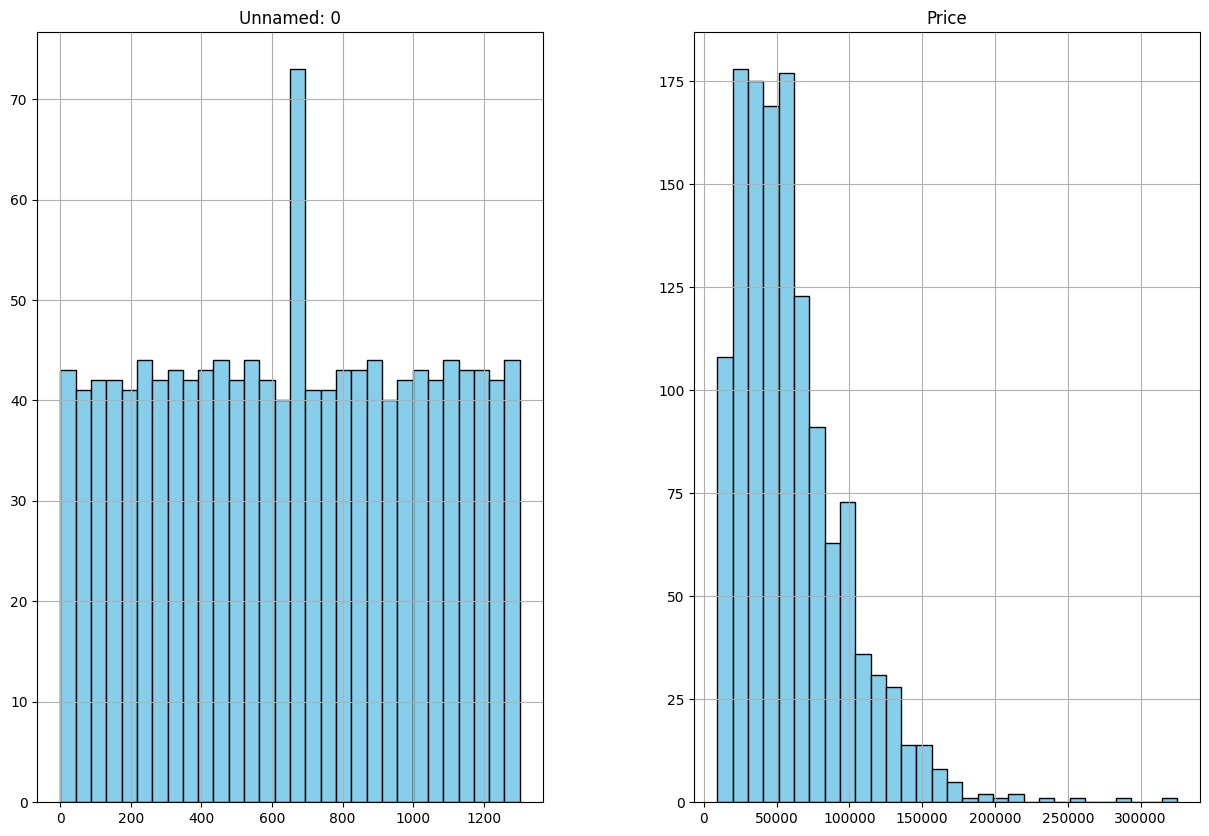

In [9]:
#IMPORT LIBRARY
import matplotlib.pyplot as plt

# DATA VISUALIZATION WITH HISTOGRAM

newlap.hist(figsize=(15,10),
            bins=30,
            color='skyblue',
            edgecolor='black')
plt.show()

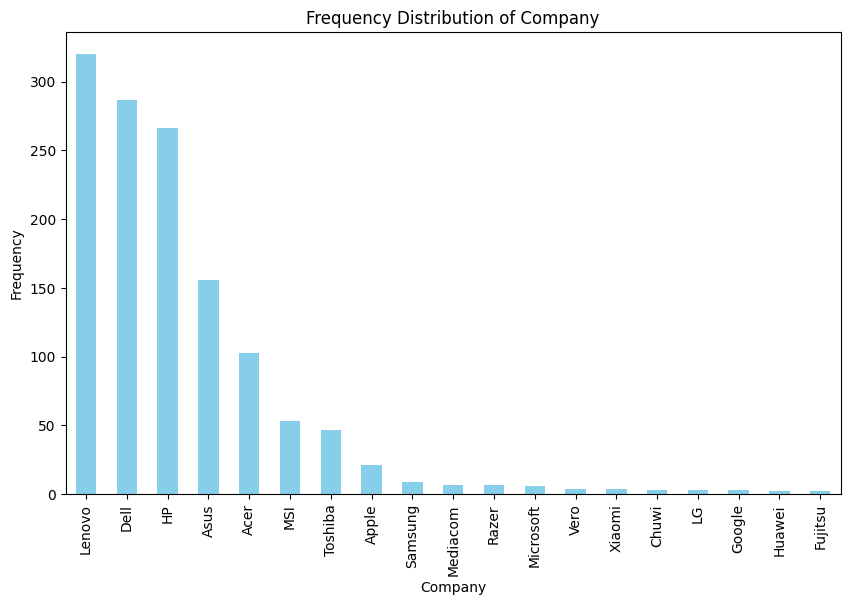

In [10]:
#Bar Plot Frequency Distribution of Company
company_freq = newlap['Company'].value_counts()  #Counts how many times a new company comes
company_freq.plot(kind='bar',figsize=(10,6),color='skyblue')
plt.xlabel('Company')
plt.ylabel('Frequency')
plt.title('Frequency Distribution of Company')
plt.show()

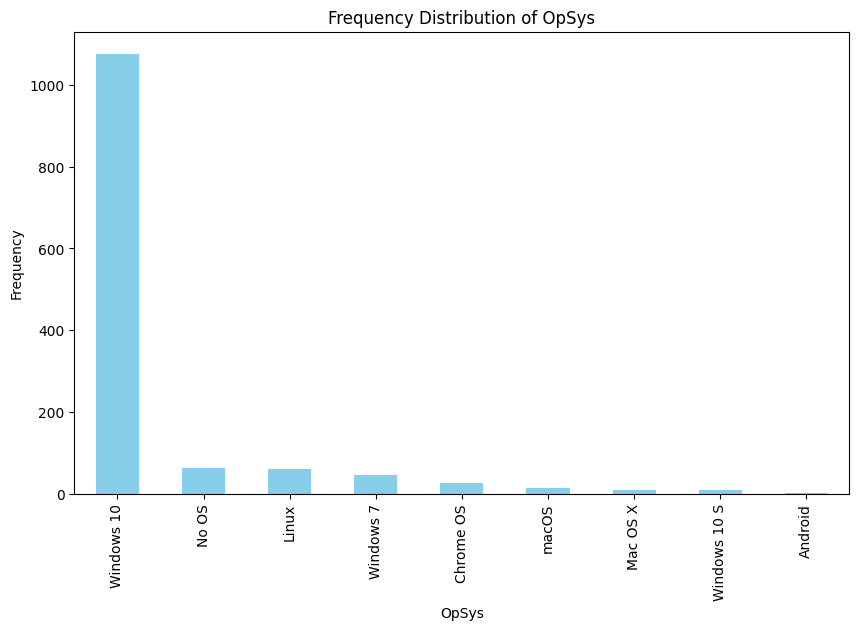

In [11]:
#Bar Plot Frequency Distribution of Operating System(OpSys)
OpSys_freq = newlap['OpSys'].value_counts()
OpSys_freq.plot(kind='bar',figsize=(10,6),color='skyblue')
plt.xlabel('OpSys')
plt.ylabel('Frequency')
plt.title('Frequency Distribution of OpSys')
plt.show()

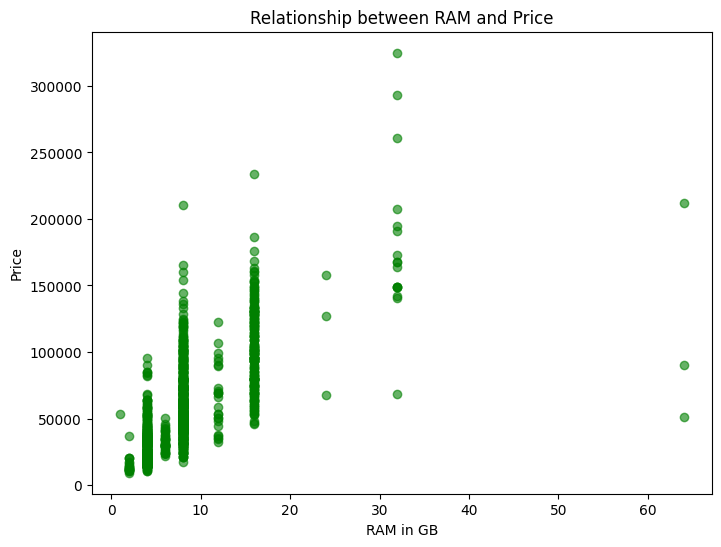

In [12]:
# Convert 'Ram' column to numeric (removing 'GB') for scatter plot
newlap['New_Ram'] = pd.to_numeric(
    newlap['Ram'].str.replace('GB','')
)

# Scatter plot between RAM and Price
plt.figure(figsize=(8,6))
plt.scatter(newlap['New_Ram'], newlap['Price'], alpha=0.6, c='green')
plt.xlabel('RAM in GB')
plt.ylabel('Price')
plt.title('Relationship between RAM and Price')
plt.show()

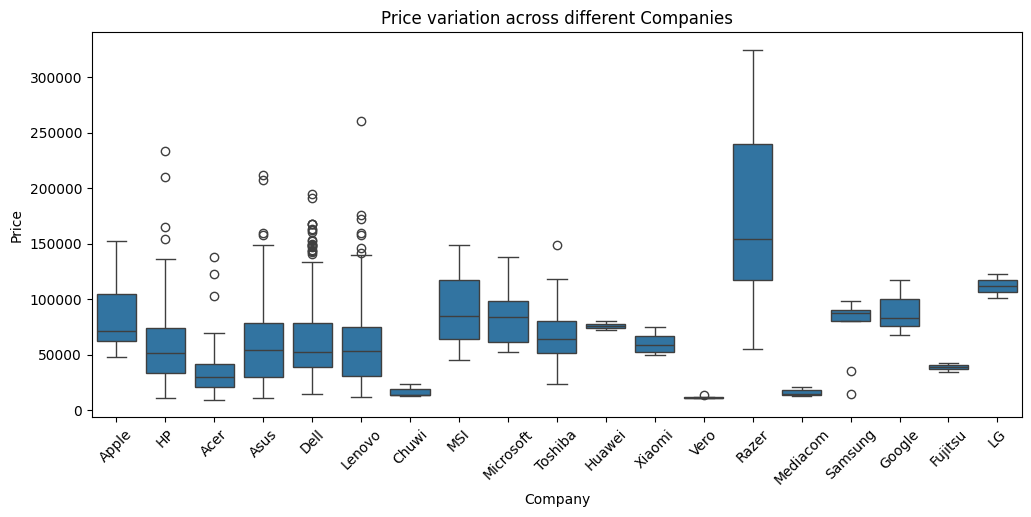

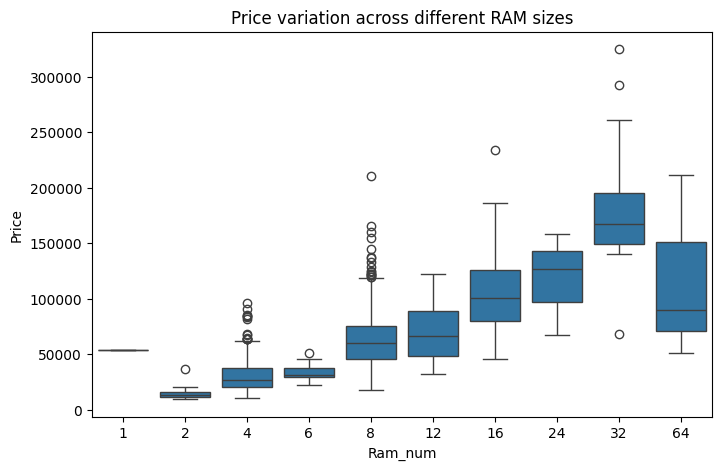

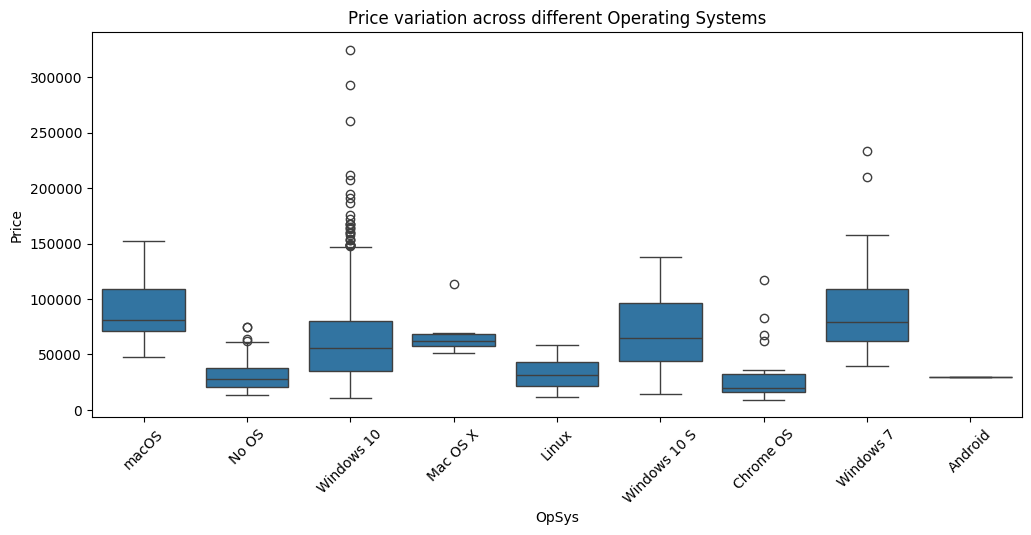

In [13]:
#Comparing PRICE with RAM , OS , COMPANY
import seaborn as sns

# Convert 'Ram' column to numeric (remove 'GB')
newlap['Ram_num'] = pd.to_numeric(
    newlap['Ram'].str.replace('GB','')
)

plt.figure(figsize=(12,5))
sns.boxplot(x='Company', y='Price', data=newlap)
plt.title('Price variation across different Companies')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x='Ram_num', y='Price', data=newlap)
plt.title('Price variation across different RAM sizes')
plt.show()

plt.figure(figsize=(12,5))
sns.boxplot(x='OpSys', y='Price', data=newlap)
plt.title('Price variation across different Operating Systems')
plt.xticks(rotation=45)
plt.show()

In [14]:
newlap=pd.read_csv('laptopData.csv')

# SORTING WEIGHT COLUMN

#REPLACING OTHER CHARACTERS WITH NaN
newlap["Weight"] = newlap["Weight"].replace("?", np.nan)
#REMOVING "KG" FROM WEIGHT COLUMN
newlap["Weight"] = newlap["Weight"].str.replace("kg", "", regex=False)
#CONVERTING TO FLOAT
newlap["Weight"] = newlap["Weight"].astype(float)

#DETECTING OUTLIERS FOR PRICE
Q1_Price = newlap["Price"].quantile(0.25)
Q3_Price = newlap["Price"].quantile(0.75)
IQR_Price = Q3_Price - Q1_Price
lower_price = Q1_Price - 1.5* IQR_Price
upper_price = Q3_Price + 1.5 * IQR_Price
outliers_price = newlap[(newlap["Price"] < lower_price) | (newlap["Price"] > upper_price)]

print("Feature: Price")
print("Number of outliers:", len(outliers_price))

#DETECTING OUTLIERS FOR WEIGHT
Q1_weight = newlap["Weight"].quantile(0.25)
Q3_weight = newlap["Weight"].quantile(0.75)
IQR_weight = Q3_weight - Q1_weight
lower_weight = Q1_weight - 1.5 * IQR_weight
upper_weight = Q3_weight + 1.5 * IQR_weight
outliers_weight = newlap[(newlap["Weight"] < lower_weight) | (newlap["Weight"] > upper_weight)]

print("\nFeature: Weight")
print("Number of outliers:", len(outliers_weight))

Feature: Price
Number of outliers: 28

Feature: Weight
Number of outliers: 55


In [15]:
# Feature Engineering

#  screen width and height from ScreenResolution
newlap[['Screen_Width', 'Screen_Height']] = newlap['ScreenResolution'].str.extract(r'(\d+)x(\d+)')

# Convert 'Ram' to numerical (remove 'GB')
newlap['Ram_GB'] = pd.to_numeric(newlap['Ram'].str.replace('GB', ''))

In [16]:
#Price per GB Ram
newlap['Price per GB Ram']=newlap['Price']/newlap['Ram_GB']

In [17]:
!pip install ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 73.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 37.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 6.1 MB/s eta 0:00:00


In [18]:
# Insights and Conclusions

In [19]:
laptop_df = pd.read_csv('laptopData.csv')

In [20]:
from ydata_profiling import ProfileReport
laptop = ProfileReport(laptop_df, title = "LAPTOP DATA-SET")
laptop

/tmp/ipykernel_1113/1762467601.py:1: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 12/12 [00:00<00:00, 28.90it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [21]:
newlap

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Screen_Width,Screen_Height,Ram_GB,Price per GB Ram
0,0.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,2560,1600,8.0,8922.3354
1,1.0,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,1440,900,8.0,5986.9404
2,2.0,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,1920,1080,8.0,3829.5000
3,3.0,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,2880,1800,16.0,8449.7085
4,4.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,2560,1600,8.0,12011.9760
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,1298.0,Lenovo,2 in 1 Convertible,14,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.80,33992.6400,1920,1080,4.0,8498.1600
1299,1299.0,Lenovo,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16GB,512GB SSD,Intel HD Graphics 520,Windows 10,1.30,79866.7200,3200,1800,16.0,4991.6700
1300,1300.0,Lenovo,Notebook,14,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,64GB Flash Storage,Intel HD Graphics,Windows 10,1.50,12201.1200,1366,768,2.0,6100.5600
1301,1301.0,HP,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6GB,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19,40705.9200,1366,768,6.0,6784.3200
